# Method 2 — In-Time Placebo Tests

**Logic:** Assign fake treatment dates in the pre-period. The SCM should *not* detect large effects at these placebo dates. If it does, the model may be over-fitting noise rather than capturing a real treatment effect.

In [3]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from numpy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')

def fit_scm(Y_pre, X_pre):
    """Solve the constrained SCM weight optimisation problem (cvxpy)."""
    if X_pre.ndim == 1:
        X_pre = X_pre.reshape(-1, 1)
    n = X_pre.shape[1]
    w = cp.Variable(n)
    prob = cp.Problem(
        cp.Minimize(cp.sum_squares(Y_pre - X_pre @ w)),
        [w >= 0, cp.sum(w) == 1]
    )
    prob.solve(solver=cp.SCS)
    return np.array(w.value).flatten()

def rmspe(a, b):
    return np.sqrt(np.mean((np.array(a) - np.array(b))**2))


## Data Preparation

In [4]:
df = pd.read_csv('./data/corridor.csv')
df['Date']        = df['Date'].astype(str).str.strip()
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'], freq='M')

y_col       = 'Rail_Vol_mt'
treated     = 'NATCOR'
treat_start = pd.Period('2022-04', freq='M')
pre_end     = treat_start - 1

wide     = df.pivot(index='Date_period', columns='Corridor', values=y_col).sort_index()
donors   = [c for c in wide.columns if c != treated]
pre_idx  = wide.index[wide.index <= pre_end]
post_idx = wide.index[wide.index >= treat_start]
treat_t  = treat_start.to_timestamp()

# Base SCM (needed for gap reference line)
w_hat  = fit_scm(wide.loc[pre_idx, treated].values,
                 wide.loc[pre_idx, donors].values)
synth  = pd.Series(wide[donors].values @ w_hat, index=wide.index, name='Synthetic')
actual = wide[treated]
gap    = actual - synth

base_pre_rmspe  = rmspe(actual[pre_idx], synth[pre_idx])
base_post_rmspe = rmspe(actual[post_idx], synth[post_idx])
base_ratio      = base_post_rmspe / base_pre_rmspe

print(f'Pre periods : {len(pre_idx)} ({pre_idx[0]} – {pre_idx[-1]})')
print(f'Post periods: {len(post_idx)} ({post_idx[0]} – {post_idx[-1]})')
print(f'Base ratio  : {base_ratio:.4f}')


Pre periods : 87 (2015-01 – 2022-03)
Post periods: 33 (2022-04 – 2024-12)
Base ratio  : 1.7140


## In-Time Placebo Estimation & Figure 2

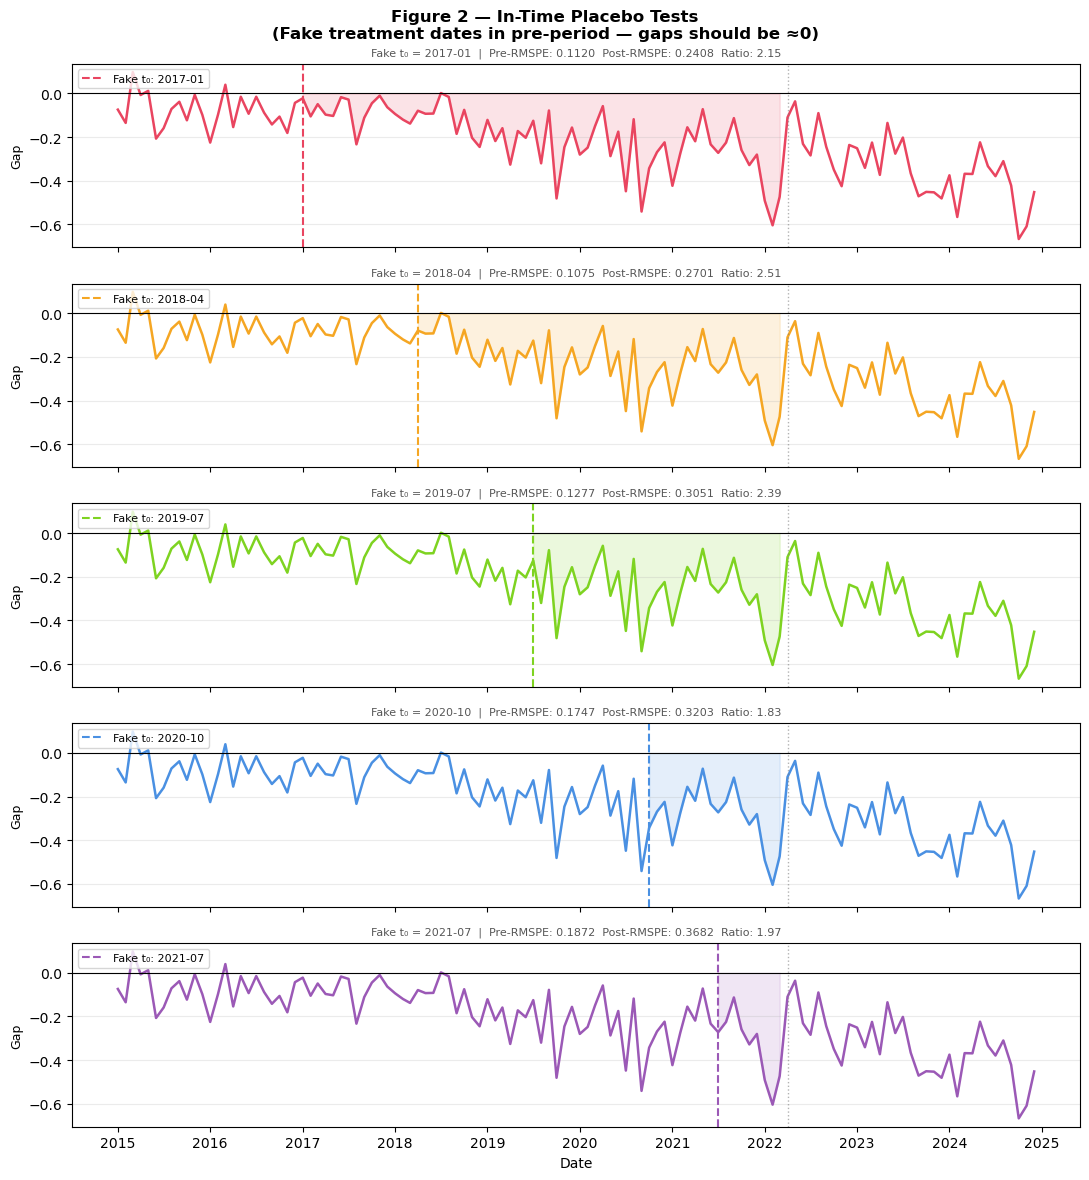

Figure saved → fig2_in_time_placebo.png


In [5]:
# ── Method 2 : In-Time Placebo Tests ──────────────────────────────────────────
# Logic: Assign fake treatment dates inside the pre-period.
# The SCM should NOT detect large effects at placebo dates.
# If it does, the model may be over-fitting noise rather than a real effect.

placebo_dates = [
    pd.Period('2017-01', freq='M'),
    pd.Period('2018-04', freq='M'),
    pd.Period('2019-07', freq='M'),
    pd.Period('2020-10', freq='M'),
    pd.Period('2021-07', freq='M'),
]
colors = ['#e94560', '#f5a623', '#7ed321', '#4a90e2', '#9b59b6']

fig, axes = plt.subplots(len(placebo_dates), 1, figsize=(11, 12), sharex=True)
fig.suptitle(
    'Figure 2 — In-Time Placebo Tests\n'
    '(Fake treatment dates in pre-period — gaps should be ≈0)',
    fontsize=12, fontweight='bold')

placebo_summary = []
for i, fake_t in enumerate(placebo_dates):
    fake_pre  = wide.index[wide.index <= (fake_t - 1)]
    fake_post = wide.index[(wide.index >= fake_t) & (wide.index < treat_start)]
    if len(fake_pre) < 12 or len(fake_post) < 6:
        continue

    w_f   = fit_scm(wide.loc[fake_pre, treated].values,
                    wide.loc[fake_pre, donors].values)
    sy_f  = pd.Series(wide[donors].values @ w_f, index=wide.index)
    gap_f = actual - sy_f
    pre_r  = rmspe(actual[fake_pre],  sy_f[fake_pre])
    post_r = rmspe(actual[fake_post], sy_f[fake_post])
    ratio_f = post_r / pre_r if pre_r > 0 else np.nan
    placebo_summary.append({
        'Fake t₀': str(fake_t),
        'Pre-RMSPE': round(pre_r, 4),
        'Post-RMSPE': round(post_r, 4),
        'Ratio': round(ratio_f, 3),
        'Exceeds base ratio': ratio_f > base_ratio
    })

    ax = axes[i]
    ax.plot(wide.index.to_timestamp(), gap_f.values, color=colors[i], lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(fake_t.to_timestamp(),  color=colors[i], lw=1.5, ls='--',
               label=f'Fake t₀: {fake_t}')
    ax.axvline(treat_t, color='grey', lw=1, ls=':', alpha=0.6)
    ax.fill_between(
        wide.index.to_timestamp(), gap_f.values, 0,
        where=(wide.index >= fake_t) & (wide.index < treat_start),
        alpha=0.15, color=colors[i])
    ax.set_ylabel('Gap', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_title(
        f'Fake t₀ = {fake_t}  |  Pre-RMSPE: {pre_r:.4f}'
        f'  Post-RMSPE: {post_r:.4f}  Ratio: {ratio_f:.2f}',
        fontsize=8, color='#555')
    ax.grid(axis='y', alpha=0.25)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('fig2_in_time_placebo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → fig2_in_time_placebo.png')


## Summary Table

In [6]:
# ── Summary table ─────────────────────────────────────────────────────────────
result_df = pd.DataFrame(placebo_summary)
print(result_df.to_string(index=False))
print(f'\nBase (true) NATCOR ratio : {base_ratio:.4f}')
print(f'Interpretation: placebo ratios BELOW base ratio supports that the true')
print(f'effect at April 2022 is not an artefact of noise or model over-fit.')
result_df


Fake t₀  Pre-RMSPE  Post-RMSPE  Ratio  Exceeds base ratio
2017-01     0.1120      0.2408  2.150                True
2018-04     0.1075      0.2701  2.512                True
2019-07     0.1277      0.3051  2.390                True
2020-10     0.1747      0.3203  1.833                True
2021-07     0.1872      0.3682  1.967                True

Base (true) NATCOR ratio : 1.7140
Interpretation: placebo ratios BELOW base ratio supports that the true
effect at April 2022 is not an artefact of noise or model over-fit.


,Fake t₀,Pre-RMSPE,Post-RMSPE,Ratio,Exceeds base ratio
0,2017-01,0.1120,0.2408,2.150,True
1,2018-04,0.1075,0.2701,2.512,True
2,2019-07,0.1277,0.3051,2.390,True
3,2020-10,0.1747,0.3203,1.833,True
4,2021-07,0.1872,0.3682,1.967,True
